In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from scipy.io import loadmat
import matplotlib.pyplot as plt

In [4]:
# Load data
z2 = loadmat('z2.mat')['z2']
z2 = np.array(z2)

# Split data into inputs and outputs
X = z2[:, :6]
Y = z2[:, 6:]

# Normalize joint angles to be between -1 and 1
Y = Y / np.pi
print(Y)

# Shuffle data
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices]
Y = Y[indices]

[[-0.5        -1.         -0.30769231 -0.5         1.         -0.25      ]
 [-0.5        -1.         -0.30769231 -0.5         1.         -0.21153846]
 [-0.5        -1.         -0.30769231 -0.5         1.         -0.17307692]
 ...
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.         -0.01923077]
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.          0.01923077]
 [ 0.19230769 -0.69230769 -0.42307692 -0.42307692  1.          0.05769231]]


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
def train_validate_test_split(x, y, train_size=0.7, validate_size=0.15, test_size=0.15, random_state=None):
    if validate_size + test_size >= 1.0:
        raise ValueError("The sum of validate_size and test_size should be less than 1.0.")
    
    x_train, x_temp, y_train, y_temp = train_test_split(x, y, train_size=train_size, random_state=random_state)
    
    remaining = 1.0 - train_size
    validate_ratio = validate_size / (validate_size + test_size)
    test_ratio = test_size / (validate_size + test_size)
    
    x_validate, x_test, y_validate, y_test = train_test_split(x_temp, y_temp, train_size=validate_ratio, test_size=test_ratio, random_state=random_state)
    
    return x_train, x_validate, x_test, y_train, y_validate, y_test

# Train-validate-test split
X_train, X_validate ,X_test, Y_train, Y_validate ,Y_test = train_validate_test_split(X, Y , train_size=0.7, validate_size=0.15, test_size=0.15, random_state=42)

# Create a fully connected neural network model with L2 regularization
model = Sequential([
    Dense(6),
    Dense(512, activation="relu", kernel_initializer='glorot_uniform', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(512, activation="relu", kernel_initializer='glorot_uniform', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(512, activation="relu", kernel_initializer='glorot_uniform', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(512, activation="relu", kernel_initializer='glorot_uniform', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(512, activation="relu", kernel_initializer='glorot_uniform', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(512, activation="relu", kernel_initializer='glorot_uniform', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(512, activation="relu", kernel_initializer='glorot_uniform', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(512, activation="relu", kernel_initializer='glorot_uniform', kernel_regularizer=tf.keras.regularizers.l2(0.01)),
    Dense(6)  # Output layer with 6 neurons (x, y, z, a, b, c)
])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint("model_z2.h5", save_best_only=True, monitor='val_loss', mode='min')

# Learning rate scheduler
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Compile the model
model.compile(optimizer=optimizer, loss='mean_squared_error', metrics=['mean_squared_error'])

# Train the model
history = model.fit(X_train, Y_train, epochs=1000, validation_data=(X_validate, Y_validate),
                    batch_size=256, shuffle=True, callbacks=[early_stopping, model_checkpoint])

Epoch 1/1000
4194/4194 [==============================] - 74s 16ms/step - loss: 2.8996 - mean_squared_error: 0.0724 - val_loss: 0.1398 - val_mean_squared_error: 0.0373
Epoch 2/1000
4194/4194 [==============================] - 64s 15ms/step - loss: 0.0698 - mean_squared_error: 0.0364 - val_loss: 0.0549 - val_mean_squared_error: 0.0354
Epoch 3/1000
4194/4194 [==============================] - 67s 16ms/step - loss: 0.0524 - mean_squared_error: 0.0346 - val_loss: 0.0503 - val_mean_squared_error: 0.0338
Epoch 4/1000
4194/4194 [==============================] - 68s 16ms/step - loss: 0.0482 - mean_squared_error: 0.0330 - val_loss: 0.0471 - val_mean_squared_error: 0.0330
Epoch 5/1000
4194/4194 [==============================] - 69s 16ms/step - loss: 0.0458 - mean_squared_error: 0.0326 - val_loss: 0.0448 - val_mean_squared_error: 0.0324
Epoch 6/1000
4194/4194 [==============================] - 66s 16ms/step - loss: 0.0442 - mean_squared_error: 0.0323 - val_loss: 0.0439 - val_mean_squared_error:

KeyboardInterrupt: 

In [2]:
# Evaluate the model on the test set
test_loss, _ = model.evaluate(X_test, Y_test)
print(f'Test Loss: {test_loss}')

NameError: name 'model' is not defined

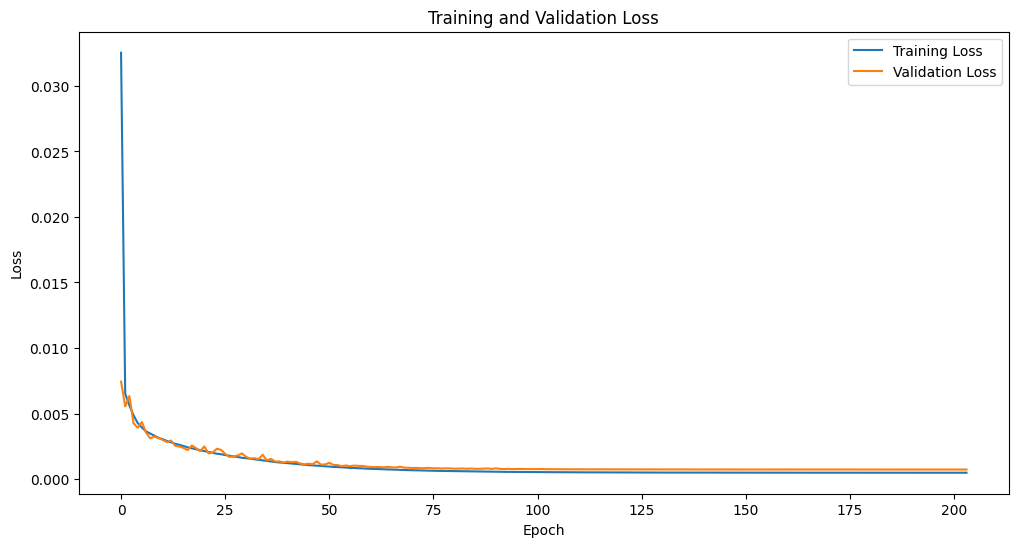

In [23]:
# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [1]:
# Plot regression curve for test set
test_predictions = model.predict(X_test) * np.pi  # Use 'model' instead of 'best_model'
# Plot the regression curve for the scaled test set with scaled figure
plt.figure(figsize=(12, 6))
plt.scatter(Y_test * np.pi, test_predictions_scaled, alpha=0.5)
plt.plot([-1, 1], [-1, 1], color='red', linestyle='--')
plt.title('Regression Curve - Scaled Test Set')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

# Set the limits for the x-axis and y-axis
plt.xlim([-1.5, 1.5])
plt.ylim([-1.5, 1.5])

plt.show()

NameError: name 'model' is not defined

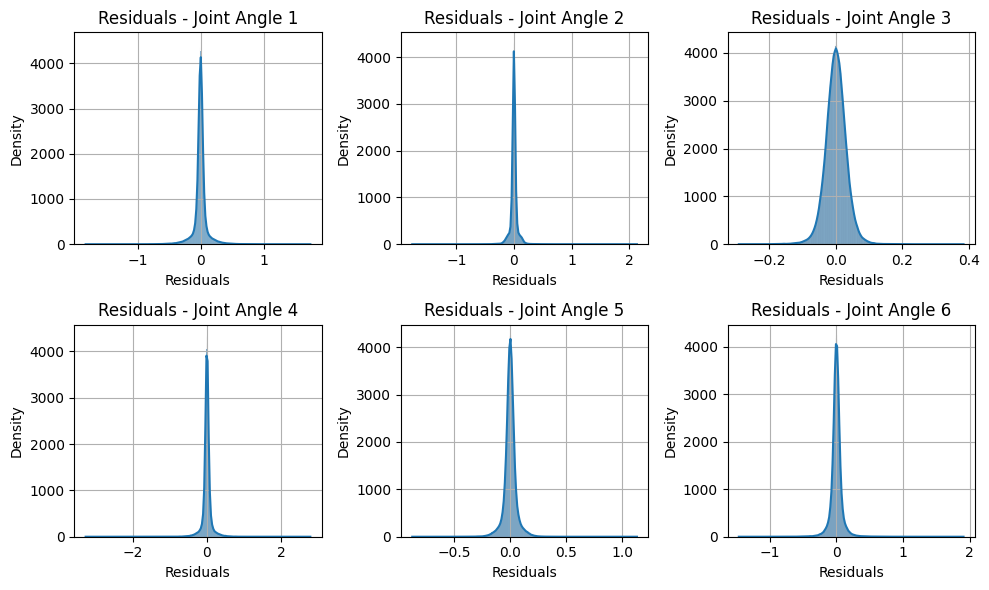

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
# Residual plots
residuals = Y_test - predictions

plt.figure(figsize=(10, 6))
for i in range(6):  # Assuming you have 6 joint angles
    plt.subplot(2, 3, i + 1)
    sns.histplot(residuals[:, i], kde=True)
    plt.title(f'Residuals - Joint Angle {i + 1}')
    plt.xlabel('Residuals')
    plt.ylabel('Density')
    plt.grid(True)

plt.tight_layout()
plt.show()

In [1]:
# Load the best model for predictions
best_model = tf.keras.models.load_model("model_z2.h5")

# Test the loaded model with [10, 20, 30, 40, 50, 60]
test_inputs = np.array([[194.5, 161.4, 283.1, 0, -90, 38.07]])
predictions = best_model.predict(test_inputs) * np.pi

print("Predictions for test inputs:")
print(predictions)

NameError: name 'tf' is not defined